In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [7]:
with open('../data/raw/train.en','r',encoding='utf-8') as f_en, open('../data/raw/train.vi','r',encoding='utf-8') as f_vi:
    for i in range(5):
        print(f"EN: {f_en.readline().strip()}")
        print(f"VI: {f_vi.readline().strip()}")

EN: It begins with a countdown.
VI: Câu chuyện bắt đầu với buổi lễ đếm ngược.
EN: On August 14th, 1947, a woman in Bombay goes into labor as the clock ticks towards midnight.
VI: Ngày 14, tháng 8, năm 1947, gần nửa đêm, ở Bombay, có một phụ nữ sắp lâm bồn.
EN: Across India, people hold their breath for the declaration of independence after nearly two centuries of British occupation and rule.
VI: Cùng lúc, trên khắp đất Ấn, người ta nín thở chờ đợi tuyên ngôn độc lập sau gần hai thập kỷ là thuộc địa của Anh.
EN: And at the stroke of midnight, a squirming infant and two new nations are born in perfect synchronicity.
VI: Khi đồng hồ điểm thời khắc nửa đêm, một đứa trẻ và hai quốc gia mới, cùng một lúc, ra đời.
EN: These events form the foundation of "Midnight's Children," a dazzling novel by the British - Indian author Salman Rushdie.
VI: Những sự kiện này là nền móng tạo nên "Những đứa con của nửa đêm," một tiểu thuyết nổi tiếng của nhà văn Anh gốc Ấn Salman Rushdie.


In [8]:
def get_lengths(filepath):
    lengths=[]
    with open(filepath,'r',encoding='utf-8') as f:
        for line in f:
            lengths.append(len(line.strip().split()))
    return np.array(lengths)

en_lengths = get_lengths('../data/raw/train.en')
vi_lengths = get_lengths('../data/raw/train.vi')

In [9]:
print(f"{len(en_lengths):,} câu.")

400,000 câu.


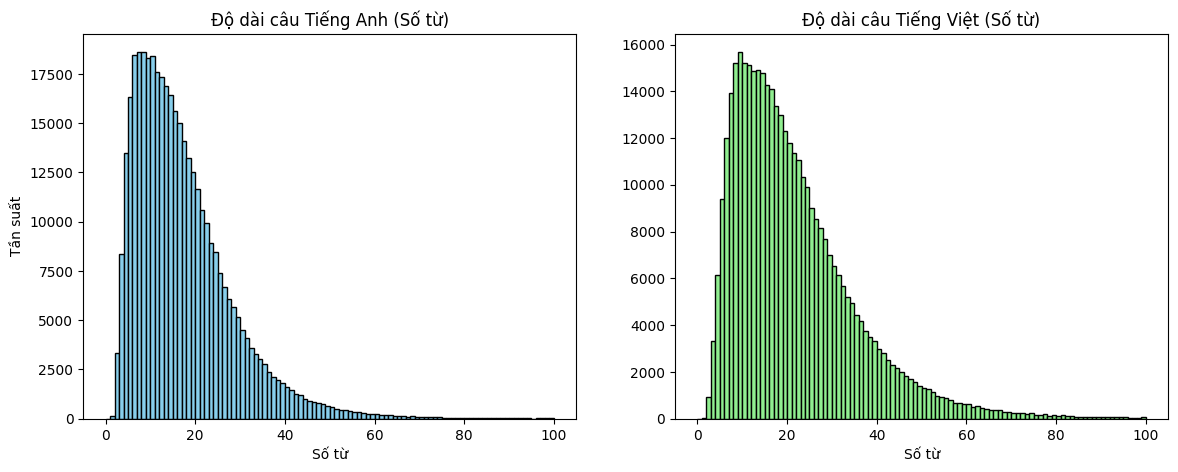

In [10]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.hist(en_lengths, bins=100, range=(0, 100), color='skyblue', edgecolor='black')
plt.title('Độ dài câu Tiếng Anh (Số từ)')
plt.xlabel('Số từ')
plt.ylabel('Tần suất')

plt.subplot(1, 2, 2)
plt.hist(vi_lengths, bins=100, range=(0, 100), color='lightgreen', edgecolor='black')
plt.title('Độ dài câu Tiếng Việt (Số từ)')
plt.xlabel('Số từ')

plt.show()

In [13]:
print("TIẾNG ANH")
print(f"Độ dài trung bình: {np.mean(en_lengths):.1f}")
print(f"90% câu ngắn hơn {np.percentile(en_lengths,90):.0f} từ")
print(f"95% câu ngắn hơn {np.percentile(en_lengths, 95):.0f} từ")
print(f"99% câu ngắn hơn {np.percentile(en_lengths, 99):.0f} từ")

TIẾNG ANH
Độ dài trung bình: 16.8
90% câu ngắn hơn 31 từ
95% câu ngắn hơn 38 từ
99% câu ngắn hơn 55 từ


In [14]:
print("TIẾNG VIỆT")
print(f"Độ dài trung bình: {np.mean(vi_lengths):.1f}")
print(f"90% câu ngắn hơn {np.percentile(vi_lengths, 90):.0f} từ")
print(f"95% câu ngắn hơn {np.percentile(vi_lengths, 95):.0f} từ")
print(f"99% câu ngắn hơn {np.percentile(vi_lengths, 99):.0f} từ")

TIẾNG VIỆT
Độ dài trung bình: 21.3
90% câu ngắn hơn 39 từ
95% câu ngắn hơn 48 từ
99% câu ngắn hơn 70 từ


In [16]:
max_len = 64
lost_en = np.sum(en_lengths > max_len) / len(en_lengths) * 100
lost_vi = np.sum(vi_lengths > max_len) / len(vi_lengths) * 100
print(f"Nếu chọn max_length = {max_len}:")
print(f"- Sẽ cắt cụt/bỏ qua {lost_en:.2f}% câu Tiếng Anh")
print(f"- Sẽ cắt cụt/bỏ qua {lost_vi:.2f}% câu Tiếng Việt")

Nếu chọn max_length = 64:
- Sẽ cắt cụt/bỏ qua 0.46% câu Tiếng Anh
- Sẽ cắt cụt/bỏ qua 1.47% câu Tiếng Việt
